# Robustness of Multilingual Intent Classification to Typos

The project **Robustness of Multilingual Intent Classification to Typos** investigates how realistic character-level spelling errors affect intent-classification systems across languages and model types. It uses MASSIVE 1.1, a multilingual natural-language-understanding dataset containing labeled user utterances and intent classes.

I completed Part 1: Data Processing. My teammates will complete Parts 2 and 3: TF-IDF with Logistic Regression, XLM-R fine-tuning, model comparison, evaluation, robustness analysis, visualizations, and error analysis.

Source: https://huggingface.co/datasets/AmazonScience/massive

## Data scope

The notebook downloads the official MASSIVE 1.1 `train`, `validation` (development), and `test` splits for English, Vietnamese, German, and Simplified Chinese. The original CSV files keep only the two fields required for intent classification:

- `utterance`: the user's text input
- `intent`: the numeric intent-class ID

Other MASSIVE metadata fields are not included in the CSV files because they are not required for intent classification and could introduce shortcuts or leakage.

## Variables

| Variable | Definition | Usage in the CSV files |
|---|---|---|
| `utterance` | The user's text request | Input text used for intent classification |
| `intent` | Numeric intent-class ID | Target label for each utterance |

## MASSIVE intent ID mapping

The `intent` values are categorical IDs, not scores or an ordered scale. Each intent represents the user's goal, such as asking about the weather, setting an alarm, sending an email, or controlling a smart-home device. The names usually combine a domain and action, for example `alarm_set`, `weather_query`, or `email_sendemail`. The official MASSIVE mapping is:

| ID | Intent | ID | Intent | ID | Intent |
|---:|---|---:|---|---:|---|
| 0 | datetime_query | 20 | play_audiobook | 40 | iot_hue_lightoff |
| 1 | iot_hue_lightchange | 21 | lists_createoradd | 41 | iot_hue_lighton |
| 2 | transport_ticket | 22 | news_query | 42 | transport_query |
| 3 | takeaway_query | 23 | alarm_query | 43 | music_likeness |
| 4 | qa_stock | 24 | iot_wemo_on | 44 | email_query |
| 5 | general_greet | 25 | general_joke | 45 | play_music |
| 6 | recommendation_events | 26 | qa_definition | 46 | audio_volume_mute |
| 7 | music_dislikeness | 27 | social_query | 47 | social_post |
| 8 | iot_wemo_off | 28 | music_settings | 48 | alarm_set |
| 9 | cooking_recipe | 29 | audio_volume_other | 49 | qa_factoid |
| 10 | qa_currency | 30 | calendar_remove | 50 | calendar_set |
| 11 | transport_traffic | 31 | iot_hue_lightdim | 51 | play_game |
| 12 | general_quirky | 32 | calendar_query | 52 | alarm_remove |
| 13 | weather_query | 33 | email_sendemail | 53 | lists_remove |
| 14 | audio_volume_up | 34 | iot_cleaning | 54 | transport_taxi |
| 15 | email_addcontact | 35 | audio_volume_down | 55 | recommendation_movies |
| 16 | takeaway_order | 36 | play_radio | 56 | iot_coffee |
| 17 | email_querycontact | 37 | cooking_query | 57 | music_query |
| 18 | iot_hue_lightup | 38 | datetime_convert | 58 | play_podcasts |
| 19 | recommendation_locations | 39 | qa_maths | 59 | lists_query |


# I. Data processing

 Downloads the official MASSIVE 1.1 training, development, and test splits for English, Vietnamese, German, and Simplified Chinese (`en-US`, `vi-VN`, `de-DE`, `zh-CN`). It then checks data quality, inspects overlaps and duplicates, creates reproducible character-level typos, prepares typo-augmented training data, prepares corrupted test examples, and manually inspects clean–corrupted sentence pairs.

In [168]:
# %pip install -U datasets pandas numpy pyarrow

from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
from datasets import load_dataset

languages = {'en-US':'english','vi-VN':'vietnamese','de-DE':'german','zh-CN':'simplified_chinese'}
noise_levels = (0.05, 0.10, 0.20)
typo_types = ('deletion','substitution','duplication','swap')
base_seed = 20261009
output_dir = Path('typo_data')
output_dir.mkdir(exist_ok=True)
print('Languages:', languages)
print('Output:', output_dir.resolve())

Languages: {'en-US': 'english', 'vi-VN': 'vietnamese', 'de-DE': 'german', 'zh-CN': 'simplified_chinese'}
Output: /Users/thopham/Documents/UZH project/EssentialsNLP/typo_data


## 1. Download official splits and retain only intent-classification fields

In [169]:
# Simple API download: MASSIVE 1.1, four languages, official splits.
from pathlib import Path
from datasets import load_dataset
import pandas as pd

languages = {'en-US':'english', 'vi-VN':'vietnamese', 'de-DE':'german', 'zh-CN':'simplified_chinese'}
output_dir = Path('typo_data')
output_dir.mkdir(exist_ok=True)
data = {}
intent_names = {}

for language in languages:
    data[language] = {}
    for split in ['train', 'validation', 'test']:
        dataset = load_dataset('AmazonScience/massive', language, split=split, trust_remote_code=True)
        if not intent_names and hasattr(dataset.features.get('intent'), 'names'):
            intent_names = dict(enumerate(dataset.features['intent'].names))
        text_column = 'utt' if 'utt' in dataset.column_names else 'text'
        frame = dataset.select_columns([text_column, 'intent']).to_pandas()
        frame = frame.rename(columns={text_column: 'utterance'})[['utterance', 'intent']]
        data[language][split] = frame
        name = 'validation' if split == 'validation' else split
        frame.to_csv(output_dir / f'{language}_{name}.csv', index=False)
        print(language, name, frame.shape)

print('Download complete.')

en-US train (11514, 2)
en-US validation (2033, 2)
en-US test (2974, 2)
vi-VN train (11514, 2)
vi-VN validation (2033, 2)
vi-VN test (2974, 2)
de-DE train (11514, 2)
de-DE validation (2033, 2)
de-DE test (2974, 2)
zh-CN train (11514, 2)
zh-CN validation (2033, 2)
zh-CN test (2974, 2)
Download complete.


## 2. Data quality checks: size, intent distribution, missing values, and duplicates



In [170]:
quality_rows, distribution_rows = [], []
for lang,splits in data.items():
    for split,frame in splits.items():
        quality_rows.append({'language':lang,'split':split,'samples':len(frame),'missing_utterance':int(frame.utterance.isna().sum()),'missing_intent':int(frame.intent.isna().sum()),'duplicate_rows':int(frame.duplicated().sum()),'duplicate_utterances':int(frame.duplicated('utterance').sum()),'empty_utterances':int(frame.utterance.fillna('').astype(str).str.strip().eq('').sum()),'unique_intents':int(frame.intent.nunique(dropna=True))})
        distribution_rows.extend({'language':lang,'split':split,'intent':int(k),'intent_name':intent_names.get(int(k), 'unknown'),'count':int(v)} for k,v in frame.intent.value_counts().sort_index().items())
quality = pd.DataFrame(quality_rows)
intent_distribution = pd.DataFrame(distribution_rows)
display(quality)

,language,split,samples,missing_utterance,missing_intent,duplicate_rows,duplicate_utterances,empty_utterances,unique_intents
0,en-US,train,11514,0,0,42,46,0,60
1,en-US,validation,2033,0,0,2,2,0,59
2,en-US,test,2974,0,0,4,4,0,59
3,vi-VN,train,11514,0,0,372,388,0,60
4,vi-VN,validation,2033,0,0,12,13,0,59
5,vi-VN,test,2974,0,0,39,39,0,59
6,de-DE,train,11514,0,0,233,247,0,60
7,de-DE,validation,2033,0,0,11,11,0,59
8,de-DE,test,2974,0,0,19,19,0,59
9,zh-CN,train,11514,0,0,460,492,0,60


### Representative data-quality summary

This visualization summarizes the number of samples, missing values, duplicates, and the intent distribution across languages and official splits.

Original cross-split overlap counts
en-US
Train-validation overlap: 11
Train-test overlap: 21
Validation-test overlap: 5
vi-VN
Train-validation overlap: 112
Train-test overlap: 159
Validation-test overlap: 46
de-DE
Train-validation overlap: 85
Train-test overlap: 109
Validation-test overlap: 26
zh-CN
Train-validation overlap: 132
Train-test overlap: 187
Validation-test overlap: 46


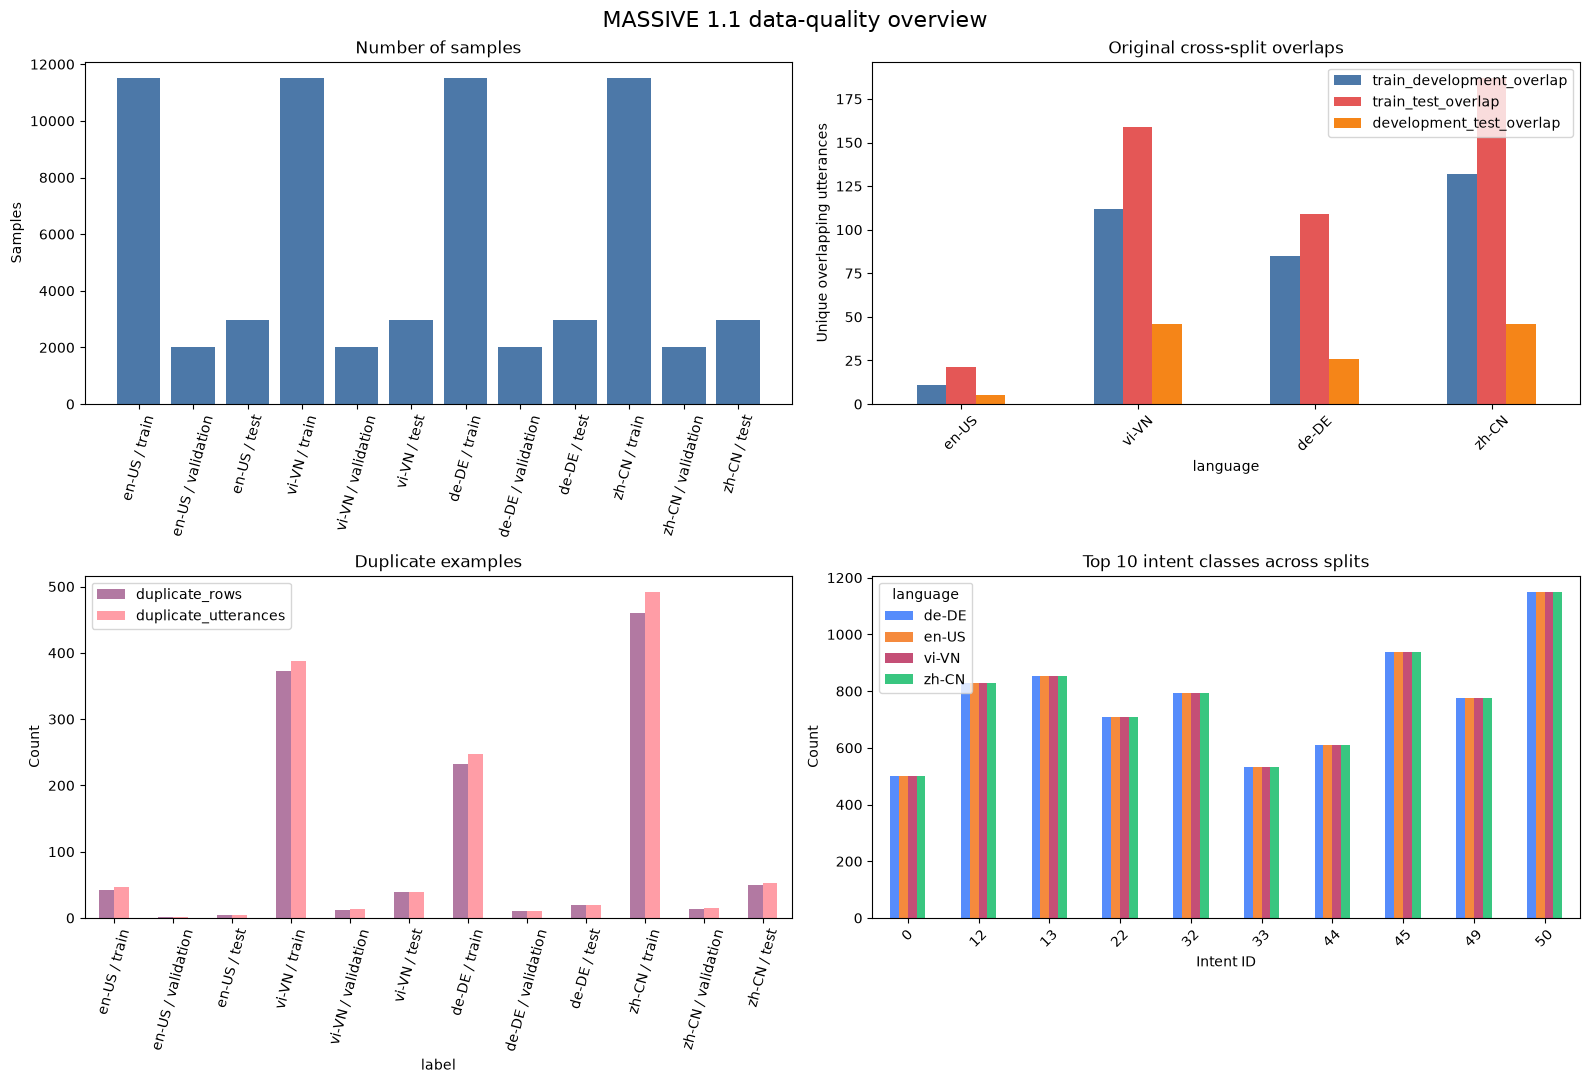

In [171]:
import matplotlib.pyplot as plt

import unicodedata
def normalize_utterance(text):
    return ' '.join(unicodedata.normalize('NFKC', str(text)).casefold().split())

leakage_rows = []
for language, splits in data.items():
    train_text = set(splits['train']['utterance'].map(normalize_utterance))
    development_text = set(splits['validation']['utterance'].map(normalize_utterance))
    test_text = set(splits['test']['utterance'].map(normalize_utterance))
    leakage_rows.append({'language': language, 'train_development_overlap': len(train_text & development_text), 'train_test_overlap': len(train_text & test_text), 'development_test_overlap': len(development_text & test_text)})
leakage = pd.DataFrame(leakage_rows)

print('Original cross-split overlap counts')
for _, row in leakage.iterrows():
    print(row['language'])
    print('Train-validation overlap:', int(row['train_development_overlap']))
    print('Train-test overlap:', int(row['train_test_overlap']))
    print('Validation-test overlap:', int(row['development_test_overlap']))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

quality_plot = quality.copy()
quality_plot['label'] = quality_plot['language'] + ' / ' + quality_plot['split']
axes[0, 0].bar(quality_plot['label'], quality_plot['samples'], color='#4C78A8')
axes[0, 0].set_title('Number of samples')
axes[0, 0].set_ylabel('Samples')
axes[0, 0].tick_params(axis='x', rotation=75)

leakage.set_index('language')[['train_development_overlap', 'train_test_overlap', 'development_test_overlap']].plot(kind='bar', ax=axes[0, 1], color=['#4C78A8', '#E45756', '#F58518'])
axes[0, 1].set_title('Original cross-split overlaps')
axes[0, 1].set_ylabel('Unique overlapping utterances')
axes[0, 1].tick_params(axis='x', rotation=45)

quality_plot.set_index('label')[['duplicate_rows', 'duplicate_utterances']].plot(kind='bar', ax=axes[1, 0], color=['#B279A2', '#FF9DA6'])
axes[1, 0].set_title('Duplicate examples')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=75)

intent_totals = intent_distribution.groupby(['language', 'intent'], as_index=False)['count'].sum()
top_intents = intent_totals.groupby('intent')['count'].sum().nlargest(10).index
intent_plot = intent_totals[intent_totals['intent'].isin(top_intents)].pivot(index='intent', columns='language', values='count').fillna(0)
intent_plot.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 intent classes across splits')
axes[1, 1].set_xlabel('Intent ID')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

fig.suptitle('MASSIVE 1.1 data-quality overview', fontsize=16)
fig.tight_layout()
plt.show()

### Remove duplicates and prepare leakage-controlled data

This step runs after the overlap visualization. It removes duplicate training utterances, removes validation utterances overlapping with test, and removes training utterances overlapping with validation or test.

In [172]:
leakage_rows, cleaned_data = [], {}
for language, splits in data.items():
    original_train = splits['train'].copy()
    # Remove only exact duplicate rows; keep identical text with different intents.
    train = original_train.drop_duplicates(subset=['utterance', 'intent'], keep='first').copy()
    development = splits['validation'].copy()
    test = splits['test'].copy()
    train_keys = train['utterance'].map(normalize_utterance)
    development_keys = development['utterance'].map(normalize_utterance)
    test_keys = test['utterance'].map(normalize_utterance)
    test_key_set = set(test_keys)
    development = development[~development_keys.isin(test_key_set)].copy()
    development_keys = development['utterance'].map(normalize_utterance)
    blocked_keys = set(development_keys) | test_key_set
    train = train[~train_keys.isin(blocked_keys)].copy()
    leakage_rows.append({'language': language, 'train_duplicates_removed': int(len(original_train) - len(original_train.drop_duplicates(subset=['utterance', 'intent']))), 'development_test_overlap_removed_from_development': int(len(splits['validation']) - len(development)), 'train_overlap_removed_against_development_test': int(len(original_train.drop_duplicates(subset=['utterance', 'intent'])) - len(train)), 'remaining_train': len(train), 'remaining_development': len(development), 'remaining_test': len(test)})
    cleaned_data[language] = {'train': train.reset_index(drop=True), 'validation': development.reset_index(drop=True), 'test': test.reset_index(drop=True)}
data = cleaned_data
print('Duplicate removal and leakage-controlled data preparation complete.')

Duplicate removal and leakage-controlled data preparation complete.


## 3. Reproducible character-level typo generator

A noise level controls the approximate fraction of eligible Unicode alphabetic characters edited in each utterance. Spaces and punctuation are preserved. Substitution characters are sampled from the same language's observed utterances, which supports Vietnamese diacritics and Simplified Chinese. Seeds are derived deterministically from the global seed, language, split, typo type, noise level, and row index.

In [173]:
import hashlib

# Create a deterministic seed for reproducible typo generation.
def stable_seed(*parts):
    key = '||'.join(map(str, (base_seed,) + parts)).encode('utf-8')
    return int.from_bytes(hashlib.sha256(key).digest()[:8], 'big') % (2**32 - 1)

# Collect valid alphabetic characters observed in one language.
def language_character_pool(language):
    texts = []
    for split_frame in data[language].values():
        texts.extend(split_frame['utterance'].dropna().astype(str).tolist())
    return sorted({char for text in texts for char in text if char.isalpha()})

character_pools = {language: language_character_pool(language) for language in languages}

# Apply one reproducible character-level typo transformation to an utterance.
def typo(text, typo_type, noise_level, seed, substitution_pool=None):
    rng, chars = random.Random(seed), list(str(text))
    eligible = [index for index, char in enumerate(chars) if char.isalpha()]
    if not eligible or noise_level <= 0:
        return ''.join(chars)
    n_edits = min(max(1, round(len(eligible) * noise_level)), len(eligible))
    if typo_type == 'swap':
        pairs = [(left, left + 1) for left in eligible[:-1] if left + 1 in eligible]
        rng.shuffle(pairs)
        used = set()
        selected = [(left, right) for left, right in pairs if not ({left, right} & used)][:n_edits]
        for left, right in sorted(selected, reverse=True):
            chars[left], chars[right] = chars[right], chars[left]
        return ''.join(chars)
    for index in sorted(rng.sample(eligible, n_edits), reverse=True):
        if typo_type == 'deletion':
            chars.pop(index)
        elif typo_type == 'duplication':
            chars.insert(index, chars[index])
        elif typo_type == 'substitution':
            pool = substitution_pool or [chars[position] for position in eligible]
            choices = [char for char in pool if char != chars[index]]
            if choices:
                replacement = rng.choice(choices)
                chars[index] = replacement.upper() if chars[index].isupper() else replacement
        else:
            raise ValueError(f'Unknown typo type: {typo_type}')
    return ''.join(chars)

print({typo_type: typo('please transfer money', typo_type, 0.10, stable_seed('demo', typo_type), character_pools['en-US']) for typo_type in typo_types})

{'deletion': 'please transfe mony', 'substitution': 'please trinscer money', 'duplication': 'please trransfeer money', 'swap': 'please trnafser money'}


## 4. Prepare typo-augmented training data

In [164]:
# Mix clean training examples with one deterministic corrupted copy per example.
def augment_training(frame, language):
    clean = frame.assign(is_corrupted=False,typo_type='none',noise_level=0.0,source_row=np.arange(len(frame)))
    rng, corrupted = random.Random(stable_seed(language,'train','augmentation')), []
    for row_id,row in frame.reset_index(drop=True).iterrows():
        typo_type, level = rng.choice(typo_types), rng.choice(noise_levels)
        corrupted.append({'utterance':typo(row.utterance,typo_type,level,stable_seed(language,'train',row_id,typo_type,level),character_pools[language]),'intent':row.intent,'is_corrupted':True,'typo_type':typo_type,'noise_level':level,'source_row':row_id})
    return pd.concat([clean,pd.DataFrame(corrupted)],ignore_index=True).sample(frac=1,random_state=stable_seed(language,'train','shuffle')).reset_index(drop=True)

augmented_train = {lang:augment_training(splits['train'],lang) for lang,splits in data.items()}

for lang,frame in augmented_train.items():
    print(lang,frame.shape,frame.is_corrupted.value_counts().to_dict())

en-US (22880, 6) {False: 11440, True: 11440}
vi-VN (21692, 6) {True: 10846, False: 10846}
de-DE (22194, 6) {False: 11097, True: 11097}
zh-CN (21494, 6) {False: 10747, True: 10747}


### Shared corrupted test sets for every language, typo type, and noise level

In [165]:
test_files = {}
for lang,splits in data.items():
    clean_test = splits['test'].reset_index(drop=True)
    for typo_type in typo_types:
        for level in noise_levels:
            rows = [{'utterance':typo(row.utterance,typo_type,level,stable_seed(lang,'test',row_id,typo_type,level),character_pools[lang]),'intent':row.intent,'source_row':row_id,'clean_utterance':row.utterance,'language':lang,'split':'test','typo_type':typo_type,'noise_level':level} for row_id,row in clean_test.iterrows()]
            test_files[(lang,typo_type,level)] = pd.DataFrame(rows)

In [166]:
inspection_rows = []
for lang,splits in data.items():
    for row_id,row in splits['test'].reset_index(drop=True).head(3).iterrows():
        for typo_type in typo_types:
            level = noise_levels[1]
            inspection_rows.append({'language':lang,'source_row':row_id,'intent':row.intent,'typo_type':typo_type,'noise_level':level,'clean_utterance':row.utterance,'corrupted_utterance':typo(row.utterance,typo_type,level,stable_seed(lang,'test',row_id,typo_type,level),character_pools[lang])})
inspection = pd.DataFrame(inspection_rows)
display(inspection)

,language,source_row,intent,typo_type,noise_level,clean_utterance,corrupted_utterance
0,en-US,0,48,deletion,0.1,wake me up at five am this week,wake me up at fve am his week
1,en-US,0,48,substitution,0.1,wake me up at five am this week,wake me up mt five am this wdek
2,en-US,0,48,duplication,0.1,wake me up at five am this week,wake me up at fiive am this weeek
3,en-US,0,48,swap,0.1,wake me up at five am this week,wake me up at five am tihs week
4,en-US,1,46,deletion,0.1,quiet,uiet
5,en-US,1,46,substitution,0.1,quiet,quiep
6,en-US,1,46,duplication,0.1,quiet,quiett
7,en-US,1,46,swap,0.1,quiet,quite
8,en-US,2,1,deletion,0.1,pink is all we need,nk is all we need
9,en-US,2,1,substitution,0.1,pink is all we need,pink is alu we neea


## 5. Data-processing conclusion

- The official MASSIVE 1.1 train, development, and test splits are preserved.
- The original download remains unchanged. The leakage-controlled training copy removes only exact duplicate `utterance` + `intent` rows; repeated utterances with different intents are kept and inspected as possible label ambiguities.

The final outputs contain clean intent data, typo-augmented training data, shared corrupted test sets, quality summaries, manual inspection pairs, and reproducibility settings.

In [167]:
# Prepare 12 separate DataFrames for model training.
required_columns = ['utterance', 'intent']
en_us_train = data['en-US']['train'][required_columns].reset_index(drop=True)
en_us_validation = data['en-US']['validation'][required_columns].reset_index(drop=True)
en_us_test = data['en-US']['test'][required_columns].reset_index(drop=True)
vi_vn_train = data['vi-VN']['train'][required_columns].reset_index(drop=True)
vi_vn_validation = data['vi-VN']['validation'][required_columns].reset_index(drop=True)
vi_vn_test = data['vi-VN']['test'][required_columns].reset_index(drop=True)
de_de_train = data['de-DE']['train'][required_columns].reset_index(drop=True)
de_de_validation = data['de-DE']['validation'][required_columns].reset_index(drop=True)
de_de_test = data['de-DE']['test'][required_columns].reset_index(drop=True)
zh_cn_train = data['zh-CN']['train'][required_columns].reset_index(drop=True)
zh_cn_validation = data['zh-CN']['validation'][required_columns].reset_index(drop=True)
zh_cn_test = data['zh-CN']['test'][required_columns].reset_index(drop=True)

training_ready = {
    'en_us_train': en_us_train, 'en_us_validation': en_us_validation, 'en_us_test': en_us_test,
    'vi_vn_train': vi_vn_train, 'vi_vn_validation': vi_vn_validation, 'vi_vn_test': vi_vn_test,
    'de_de_train': de_de_train, 'de_de_validation': de_de_validation, 'de_de_test': de_de_test,
    'zh_cn_train': zh_cn_train, 'zh_cn_validation': zh_cn_validation, 'zh_cn_test': zh_cn_test
}
display(pd.DataFrame([{'dataframe': name, 'rows': len(frame), 'columns': list(frame.columns)} for name, frame in training_ready.items()]))


,dataframe,rows,columns
0,en_us_train,11440,"[utterance, intent]"
1,en_us_validation,2028,"[utterance, intent]"
2,en_us_test,2974,"[utterance, intent]"
3,vi_vn_train,10846,"[utterance, intent]"
4,vi_vn_validation,1981,"[utterance, intent]"
5,vi_vn_test,2974,"[utterance, intent]"
6,de_de_train,11097,"[utterance, intent]"
7,de_de_validation,2002,"[utterance, intent]"
8,de_de_test,2974,"[utterance, intent]"
9,zh_cn_train,10747,"[utterance, intent]"
